# 03. Content-Based Filtering

개인화 상품 추천 엔진 프로젝트의 Day 3 산출물입니다.  
이 노트북에서는 **장르 + 개봉 decade** 기반 item profile과 user profile을 구성하고, Content-Based 추천 성능을 평가합니다.

## ?????
- [x] ?? one-hot / multi-hot feature ??
- [x] ?? decade feature ??
- [x] MovieLens 100K? tag ?? ??
- [x] TF-IDF metadata feature ??
- [x] item profile / user profile ??
- [x] cosine similarity ?? ??
- [x] Precision@K / Recall@K / NDCG@K / MAP ??
- [x] Coverage / Intra-list Diversity ??
- [x] popularity baseline? ??
- [x] cold-start item ?? ?? ??

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import DEFAULT_TOP_K, HIGH_RATING_THRESHOLD, RANDOM_SEED
from src.data import build_relevance_sets, load_bundle, random_train_test_split
from src.evaluation import evaluate_recommendations
from src.features import (
    build_item_feature_matrix,
    build_item_similarity_matrix,
    build_tfidf_item_feature_matrix,
    build_user_profile_matrix,
    recommend_content_based,
    score_user_item_content,
)
from src.models import recommend_popular_items

sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_SEED)


In [2]:
content_feature_source = "src.features.content_based"
helper_import_error = None
content_feature_source, helper_import_error


('src.features.content_based', None)

## 1. 데이터 로드
Day 1 / Day 2와 동일한 split 전략을 재사용합니다.

In [3]:
# bundle = load_bundle(download_if_missing=True)  # 네트워크가 가능한 환경에서만 사용
bundle = load_bundle(download_if_missing=False)
ratings = bundle.ratings
items = bundle.items

train_df, test_df = random_train_test_split(ratings, test_size=0.2)
relevant_items = build_relevance_sets(test_df, min_rating=HIGH_RATING_THRESHOLD)
catalog = sorted(train_df["item_id"].unique())

pd.DataFrame({
    "rows": [len(train_df), len(test_df)],
}, index=["train", "test"])


,rows
train,80000
test,20000


## 2. MovieLens 100K의 tag 한계 확인
MovieLens 100K는 최신 MovieLens 변형과 달리 별도 tag 테이블이 없어, **장르 + 개봉 decade**를 기본 feature set으로 사용합니다.

In [4]:
tag_availability = pd.Series({
    "tag_feature_available": False,
    "default_feature_strategy": "genres + release_decade",
    "note": "MovieLens 100K는 tag 기반 TF-IDF 실험을 바로 수행하기 어렵다.",
})
tag_availability


tag_feature_available                                                False
default_feature_strategy                           genres + release_decade
note                        MovieLens 100K는 tag 기반 TF-IDF 실험을 바로 수행하기 어렵다.
dtype: object

## 3. Item profile 구성

In [5]:
genre_decade_features = build_item_feature_matrix(items)
tfidf_item_features = build_tfidf_item_feature_matrix(items)
item_features = tfidf_item_features.copy()

pd.DataFrame(
    {
        'feature_family': ['genre_decade', 'tfidf_metadata'],
        'n_items': [len(genre_decade_features), len(tfidf_item_features)],
        'n_features': [genre_decade_features.shape[1], tfidf_item_features.shape[1]],
        'density': [float((genre_decade_features > 0).mean().mean()), float((tfidf_item_features > 0).mean().mean())],
    }
)

,feature_family,n_items,n_features,density
0,genre_decade,1682,28,0.097142
1,tfidf_metadata,1682,837,0.006727


In [6]:
item_features.iloc[:5, :12]

,tfidf_ace,tfidf_ace ventura,tfidf_action,tfidf_action adventure,tfidf_action childrens,tfidf_action comedy,tfidf_action crime,tfidf_action decade_1990,tfidf_action drama,tfidf_action horror,tfidf_action mystery,tfidf_action romance
item_id,,,,,,,,,,,,
1,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.303437,0.428908,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.352475,0.000000,0.0,0.643552,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


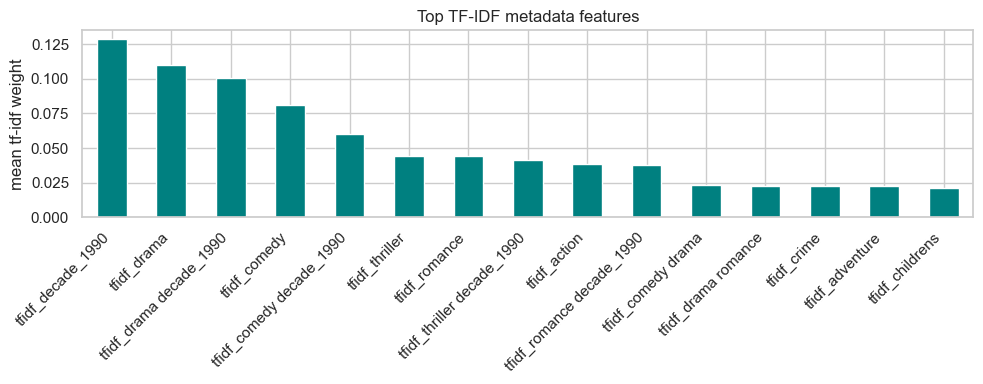

In [7]:
top_terms = item_features.mean().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 4))
top_terms.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Top TF-IDF metadata features')
ax.set_ylabel('mean tf-idf weight')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. User profile 구성

In [8]:
user_profiles = build_user_profile_matrix(
    train_df,
    item_features,
    min_rating=HIGH_RATING_THRESHOLD,
)
user_profiles.shape


(942, 837)

In [9]:
user_profiles.head()


,tfidf_ace,tfidf_ace ventura,tfidf_action,tfidf_action adventure,tfidf_action childrens,tfidf_action comedy,tfidf_action crime,tfidf_action decade_1990,tfidf_action drama,tfidf_action horror,...,tfidf_wonderful,tfidf_wonderland,tfidf_wood,tfidf_world,tfidf_wrong,tfidf_year,tfidf_york,tfidf_york action,tfidf_young,tfidf_young guns
1,0.0,0.0,0.170200,0.086944,0.0,0.027690,0.015257,0.000000,0.029929,0.020114,...,0.0,0.000000,0.034553,0.019561,0.022829,0.0,0.0,0.0,0.017284,0.0
2,0.0,0.0,0.107753,0.049234,0.0,0.000000,0.091796,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0
3,0.0,0.0,0.074709,0.035253,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0
4,0.0,0.0,0.151307,0.090421,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.168603,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0
5,0.0,0.0,0.276805,0.215168,0.0,0.110405,0.000000,0.053595,0.000000,0.017473,...,0.0,0.000000,0.000000,0.000000,0.063683,0.0,0.0,0.0,0.024108,0.0


## 5. Content-Based 추천 생성

In [10]:
content_recommendations, user_profiles, content_score_matrix = recommend_content_based(
    train_df,
    item_features,
    user_ids=sorted(test_df["user_id"].unique()),
    top_k=DEFAULT_TOP_K,
)

sample_user = next(iter(content_recommendations))
sample_user, content_recommendations[sample_user][:10]


(1, [920, 658, 1648, 1590, 1380, 1488, 697, 880, 1282, 937])

## 6. 평가: 정확도 + 다양성 + 커버리지

In [11]:
item_similarity = build_item_similarity_matrix(item_features)
content_summary, content_user_rows = evaluate_recommendations(
    recommendations=content_recommendations,
    ground_truth=relevant_items,
    k=DEFAULT_TOP_K,
    catalog=catalog,
    item_similarity=item_similarity,
    return_user_metrics=True,
)
content_summary["model_name"] = "content_tfidf_metadata"
content_summary


{'users_evaluated': 926.0,
 'precision@10': 0.016738660907127396,
 'recall@10': 0.02140745758143516,
 'ndcg@10': 0.024560363586675085,
 'map@10': 0.010887300444535857,
 'intra_list_diversity': 0.1751126604937882,
 'coverage': 0.3692493946731235,
 'model_name': 'content_tfidf_metadata'}

In [12]:
content_user_metrics_df = pd.DataFrame(content_user_rows)
content_user_metrics_df.head()


,user_id,precision@10,recall@10,ndcg@10,ap@10,intra_list_diversity
0,1,0.0,0.00,0.00000,0.00,-2.220446e-16
1,2,0.0,0.00,0.00000,0.00,-2.220446e-16
2,3,0.0,0.00,0.00000,0.00,-2.220446e-16
3,4,0.1,0.25,0.15102,0.05,1.627543e-01
4,5,0.0,0.00,0.00000,0.00,-2.220446e-16


## 7. 인기도 baseline과 비교

In [13]:
target_user_ids = sorted(test_df["user_id"].unique())
popular_recommendations = recommend_popular_items(train_df, user_ids=target_user_ids, top_k=DEFAULT_TOP_K)
popular_summary = evaluate_recommendations(
    recommendations=popular_recommendations,
    ground_truth=relevant_items,
    k=DEFAULT_TOP_K,
    catalog=catalog,
    item_similarity=item_similarity,
)
popular_summary["model_name"] = "popularity_baseline"

comparison_df = pd.DataFrame([content_summary, popular_summary])[
    ["model_name", f"precision@{DEFAULT_TOP_K}", f"recall@{DEFAULT_TOP_K}", f"ndcg@{DEFAULT_TOP_K}", f"map@{DEFAULT_TOP_K}", "coverage", "intra_list_diversity"]
]
comparison_df


,model_name,precision@10,recall@10,ndcg@10,map@10,coverage,intra_list_diversity
0,content_tfidf_metadata,0.016739,0.021407,0.024560,0.010887,0.369249,0.175113
1,popularity_baseline,0.134665,0.140311,0.175515,0.090632,0.029056,0.908596


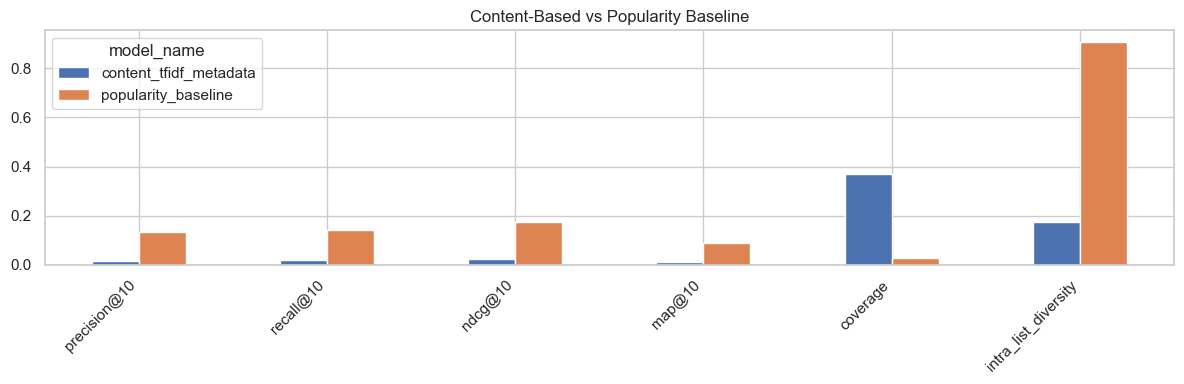

In [14]:
metric_cols = [f"precision@{DEFAULT_TOP_K}", f"recall@{DEFAULT_TOP_K}", f"ndcg@{DEFAULT_TOP_K}", f"map@{DEFAULT_TOP_K}", "coverage", "intra_list_diversity"]
comparison_plot_df = comparison_df.set_index("model_name")[metric_cols]
fig, ax = plt.subplots(figsize=(12, 4))
comparison_plot_df.T.plot(kind="bar", ax=ax)
ax.set_title("Content-Based vs Popularity Baseline")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 8. Cold-start item 관점 분석

In [15]:
item_counts = train_df.groupby("item_id")["user_id"].count()
cold_start_items = set(item_counts[item_counts < 5].index)

def cold_start_share(recommendations: dict[int, list[int]]) -> float:
    recommended = [item for items in recommendations.values() for item in items]
    if not recommended:
        return 0.0
    return sum(item in cold_start_items for item in recommended) / len(recommended)

cold_start_compare = pd.DataFrame({
    "model_name": ["content_tfidf_metadata", "popularity_baseline"],
    "cold_start_item_share": [
        cold_start_share(content_recommendations),
        cold_start_share(popular_recommendations),
    ],
})
cold_start_compare


,model_name,cold_start_item_share
0,content_tfidf_metadata,0.23312
1,popularity_baseline,0.00000


## 9. ?? ? ?? ??
- MovieLens 100K?? ?? tag table? ???, **title token + genre + decade**? ?? metadata TF-IDF? ??? ??? ??????.
- Content-Based? Top-10 ???? ??? **coverage? cold-start item ??**?? ??? ??? ????.
- ??? ?? ??? ?? ????? Content-Based? ?? ??, ????? ??? Hybrid? ??? ??? ???????.

In [16]:
metrics_dir = PROJECT_ROOT / "artifacts" / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)
comparison_df.to_csv(metrics_dir / "day3_content_based_results.csv", index=False)
content_user_metrics_df.to_csv(metrics_dir / "day3_content_based_user_metrics.csv", index=False)
cold_start_compare.to_csv(metrics_dir / "day3_content_based_cold_start_compare.csv", index=False)
comparison_df


,model_name,precision@10,recall@10,ndcg@10,map@10,coverage,intra_list_diversity
0,content_tfidf_metadata,0.016739,0.021407,0.024560,0.010887,0.369249,0.175113
1,popularity_baseline,0.134665,0.140311,0.175515,0.090632,0.029056,0.908596
